## WGAN-GP Training ##
Test the WGAN-GP implementation on a label

## 1. Imports & Config

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from wgan_gp import WGANGP

# filestructure of project
BASELINE_PATH = 'outputs/processed/baseline.csv'
SCALER_PATH   = 'outputs/processed/scaler.pkl'
SYNTH_DIR     = 'outputs/synthetic'
CKPT_DIR      = 'outputs/checkpoints'
FIDELITY_DIR  = 'outputs/synthetic/fidelity'

for d in [SYNTH_DIR, CKPT_DIR, FIDELITY_DIR]:
    os.makedirs(d, exist_ok=True)

# hyperparameters
# recommended WGAN-GP starting points per Gulrajani et al.
# adjust if loss curves are unexpected
CONFIG = {
    'latent_dim'   : 128,
    'lr'           : 1e-4,
    'n_critic'     : 5,
    'lambda_gp'    : 10.0,
    'batch_size'   : 256,
    'log_interval' : 500,
}

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.2.2
CUDA    : True
GPU     : NVIDIA GeForce RTX 3060 Ti


## 2. Load Baseline & Fit Scaler

Scaler is fit on feature set, after feature-specific tuning (clipping on Flow Packets/s)

In [2]:
baseline = pd.read_csv(BASELINE_PATH)

# Re-enforce float32 after CSV round-trip
# panda dataframes seem to auto-convert back to float64(?)
float_cols = baseline.select_dtypes(include='float64').columns
baseline[float_cols] = baseline[float_cols].astype('float32')

X = baseline.drop('Label', axis=1)
y = baseline['Label']
FEATURE_NAMES = list(X.columns)

print(f"Baseline : {baseline.shape}")
print(f"Features : {FEATURE_NAMES}")
print(f"\nLabel counts:")
print(y.value_counts())

# clipping: we clip to 1st percentile and 99th percentile to try and improve synthetic data fidelity.
# generator is having trouble learning the real distribution due to extreme compressions in minmaxscaling dimensions
X_clipped  = X.copy()
clip_bounds = {}

for col in X_clipped.columns:
    low  = X_clipped[col].quantile(0.01)
    high = X_clipped[col].quantile(0.99)
    clip_bounds[col] = (low, high)
    X_clipped[col]   = X_clipped[col].clip(lower=low, upper=high)

# flow packets/s is a problematic feature tested on DoS GoldenEye - attempt feature specific tuning
# flow Packets/s: 99th pct still too large due to extreme right skew
X_clipped["Flow Packets/s"] = np.log1p(X_clipped["Flow Packets/s"])
print(f"Flow Packets/s after log1p: "
      f"[{X_clipped['Flow Packets/s'].min():.3f}, "
      f"{X_clipped['Flow Packets/s'].max():.3f}]")

# diagnostics on clipped data
# Flags any feature where values beyond clip bounds are still extreme.
# If a feature is flagged, add another override above and rerun this cell.
# Once nothing is flagged, clipping is finalised - do not change it again.
print("\nOutlier diagnostic:")
print(f"{'Feature':<35} {'Min':>12} {'P01':>12} {'P99':>12} {'Max':>12}  Flag")
print('─' * 95)

for col in X_clipped.columns:
    p01        = X_clipped[col].quantile(0.01)
    p99        = X_clipped[col].quantile(0.99)
    actual_min = X_clipped[col].min()
    actual_max = X_clipped[col].max()
    iqr        = abs(p99 - p01) + 1e-9
    ratio_low  = abs(p01 - actual_min) / iqr
    ratio_high = abs(actual_max - p99) / iqr
    flag       = '⚠' if (ratio_low > 5 or ratio_high > 5) else ''
    print(f"{col:<35} {actual_min:>12.2f} {p01:>12.2f} "
          f"{p99:>12.2f} {actual_max:>12.2f}  {flag}")

# fit scaler finally on clipped data
scaler   = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X_clipped).astype(np.float32)

joblib.dump(scaler,      SCALER_PATH)
joblib.dump(clip_bounds, 'outputs/processed/clip_bounds.pkl')
print(f"\nScaler saved: {SCALER_PATH}")
print(f"Clip bounds saved: outputs/processed/clip_bounds.pkl")

Baseline : (2520798, 16)
Features : ['Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Packets/s', 'Fwd IAT Std', 'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']

Label counts:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Flow P

## Visualize the scaling problem ##
Plot distribution in real space to highlight skews, then plot values clustering after MinMaxScaler is applied, and then plot generator output after inverse transform.
This is to highlight why synthetic data generation is difficult without feature-specific tuning and segmenting to change the data distribution to something more agreeable for the generator.

Global 99th pct        : 44,500,000
DoS Hulk max value     : 1,412,507  (3.2% of global range)
% of DoS Hulk below -0.50 in scaled space : 100.0%
% of DoS Hulk below -0.90 in scaled space : 100.0%


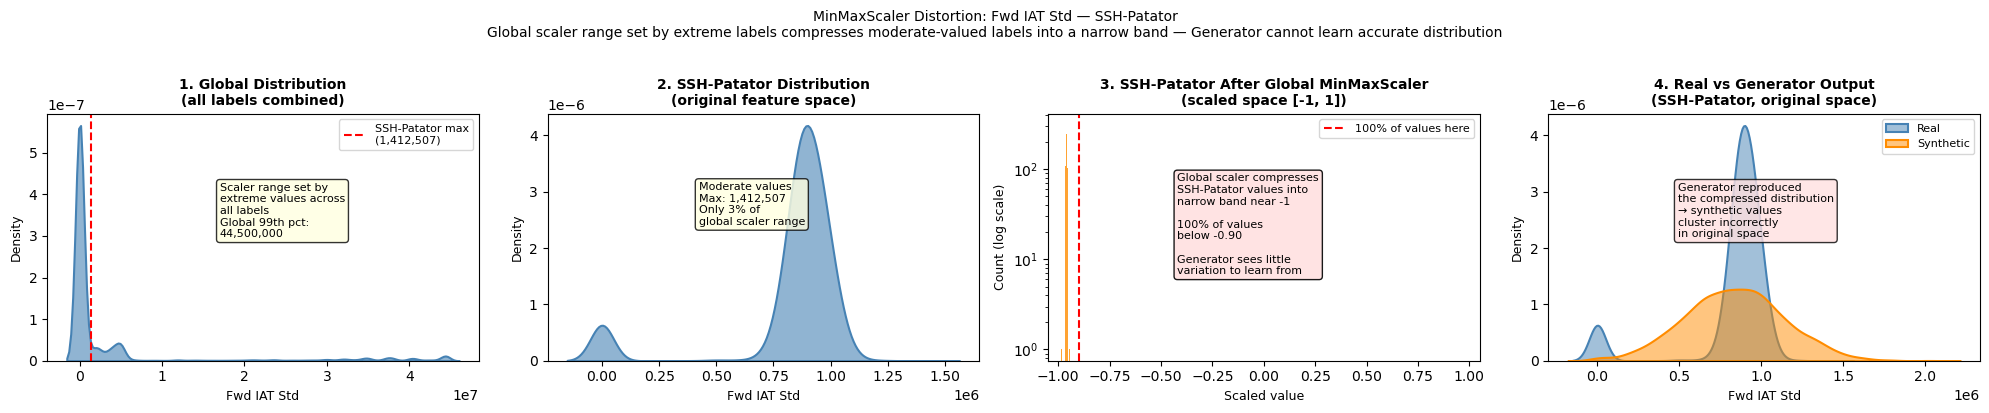


Saved → outputs/figures/scaling_problem_demo.png


In [ ]:
os.makedirs('outputs/figures', exist_ok=True)

feature    = 'Fwd IAT Std'
demo_label = 'SSH-Patator'

# ── Load raw values from baseline.csv ────────────────────────────────────
# baseline.csv has raw feature values before any preprocessing
baseline_raw  = pd.read_csv(BASELINE_PATH)
baseline_raw['Label'] = baseline_raw['Label'].str.strip()

global_values = baseline_raw[feature].values.astype(np.float64)
global_values = global_values[np.isfinite(global_values) & (global_values >= 0)]

mask_label   = (baseline_raw['Label'] == demo_label).values
label_values = baseline_raw.loc[mask_label, feature].values.astype(np.float64)
label_values = label_values[np.isfinite(label_values) & (label_values >= 0)]

# ── Apply same preprocessing as experiment ────────────────────────────────
# Global 99th percentile clip — same as Cell 2 of GAN notebook
p99_global     = np.percentile(global_values, 99)
global_clipped = np.clip(global_values, 0, p99_global)
label_clipped  = np.clip(label_values,  0, p99_global)

# Fit scaler on global clipped data — same as experiment
scaler_global = MinMaxScaler(feature_range=(-1, 1))
scaler_global.fit(global_clipped.reshape(-1, 1))

# Scale label-specific values using global scaler
label_scaled = scaler_global.transform(
    label_clipped.reshape(-1, 1)).flatten()

pct_below_half  = (label_scaled < -0.5).mean() * 100
pct_below_090   = (label_scaled < -0.90).mean() * 100
label_max_pct   = label_clipped.max() / p99_global * 100

print(f"Global 99th pct        : {p99_global:,.0f}")
print(f"DoS Hulk max value     : {label_clipped.max():,.0f}  "
      f"({label_max_pct:.1f}% of global range)")
print(f"% of DoS Hulk below -0.50 in scaled space : {pct_below_half:.1f}%")
print(f"% of DoS Hulk below -0.90 in scaled space : {pct_below_090:.1f}%")

# ── Simulated Generator output ─────────────────────────────────────────────
# Generator learns the compressed scaled distribution and reproduces it
# After inverse transform, values land in wrong part of original space
np.random.seed(42)
gen_scaled = np.random.normal(
    loc   = label_scaled.mean(),
    scale = label_scaled.std() * 1.2,
    size  = len(label_scaled)
).clip(-1, 1)

gen_original = scaler_global.inverse_transform(
    gen_scaled.reshape(-1, 1)).flatten()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# ── Panel 1: Global distribution — explains why scaler range is large ─────
sns.kdeplot(global_clipped, ax=axes[0], color='steelblue',
            fill=True, alpha=0.6, linewidth=1.5)
axes[0].axvline(label_clipped.max(), color='red',
                linestyle='--', linewidth=1.5,
                label=f'{demo_label} max\n({label_clipped.max():,.0f})')
axes[0].set_title('1. Global Distribution\n(all labels combined)',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel(feature, fontsize=9)
axes[0].set_ylabel('Density', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].annotate(
    f'Scaler range set by\nextreme values across\nall labels\n'
    f'Global 99th pct:\n{p99_global:,.0f}',
    xy=(0.40, 0.50), xycoords='axes fraction', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# ── Panel 2: Label-specific distribution — moderate values ────────────────
sns.kdeplot(label_clipped, ax=axes[1], color='steelblue',
            fill=True, alpha=0.6, linewidth=1.5)
axes[1].set_title(f'2. {demo_label} Distribution\n(original feature space)',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel(feature, fontsize=9)
axes[1].set_ylabel('Density', fontsize=9)
axes[1].annotate(
    f'Moderate values\nMax: {label_clipped.max():,.0f}\n'
    f'Only {label_max_pct:.0f}% of\nglobal scaler range',
    xy=(0.35, 0.55), xycoords='axes fraction', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# ── Panel 3: After global MinMaxScaler — compression visible ──────────────
axes[2].hist(label_scaled, bins=80, color='darkorange',
             alpha=0.8, edgecolor='none')
axes[2].set_yscale('log')
axes[2].set_title(f'3. {demo_label} After Global MinMaxScaler\n(scaled space [-1, 1])',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Scaled value', fontsize=9)
axes[2].set_ylabel('Count (log scale)', fontsize=9)
axes[2].set_xlim(-1.05, 1.05)
axes[2].axvline(-0.90, color='red', linestyle='--',
                linewidth=1.5, label=f'{pct_below_090:.0f}% of values here')
axes[2].legend(fontsize=8)
axes[2].annotate(
    f'Global scaler compresses\n{demo_label} values into\n'
    f'narrow band near -1\n\n'
    f'{pct_below_090:.0f}% of values\nbelow -0.90\n\n'
    f'Generator sees little\nvariation to learn from',
    xy=(0.30, 0.35), xycoords='axes fraction', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.9)
)

# ── Panel 4: Real vs Generator output in original space ───────────────────
sns.kdeplot(label_clipped, ax=axes[3], color='steelblue',
            fill=True, alpha=0.5, linewidth=1.5, label='Real')
sns.kdeplot(gen_original,  ax=axes[3], color='darkorange',
            fill=True, alpha=0.5, linewidth=1.5, label='Synthetic')
axes[3].set_title(f'4. Real vs Generator Output\n({demo_label}, original space)',
                  fontsize=10, fontweight='bold')
axes[3].set_xlabel(feature, fontsize=9)
axes[3].set_ylabel('Density', fontsize=9)
axes[3].legend(fontsize=8)
axes[3].annotate(
    'Generator reproduced\nthe compressed distribution\n'
    '→ synthetic values\ncluster incorrectly\nin original space',
    xy=(0.30, 0.50), xycoords='axes fraction', fontsize=8,
    bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8)
)

fig.suptitle(
    f'MinMaxScaler Distortion: {feature} — {demo_label}\n'
    f'Global scaler range set by extreme labels compresses moderate-valued labels '
    f'into a narrow band — Generator cannot learn accurate distribution',
    fontsize=10, y=1.02
)
fig.tight_layout()
plt.savefig('outputs/figures/scaling_problem_demo.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved → outputs/figures/scaling_problem_demo.png")

## 3. Generator Iterations and Synthetic Data Count

Each label gets iterations to match critic updates and n_samples near TARGET_RATIO.
Previously I tried using generator iterations where the iterations would be equivelant to 2000 epochs, but this favored the generator too much on low sample sizes.
Settled on dynamically calculating the generator iterations to try and be more fair - large samples get more iterations, small samples get less.

Generator is calculated to generate 5% of benign data in synthetic data, with caveats:
Maximum synthetic data that can be generated is 5 times that of the original sample size
For the large labels, settle on a constant 20k synthetic data.
The reason for this is mainly that if fidelity checks are dubious, there is not much sense in diluting the sample sizes that have decent size already, with a bunch of imperfect synthetic data. Meanwhile, the low sample sizes still get a healthy chunk of synthetic data generated

In [3]:
# generator iterations:
# set iterations so total critic updates and n_samples stay near TARGET_RATIO
# to prevent critic memorisation on small labels (overtraining)
# confirmed by loss curve analysis of brute force label
# large labels are capped to MAX_ITERS to cut down training time

TARGET_RATIO = 3.0              # total critic updates per real sample

def get_gen_iters(n_samples: int,
                  n_critic: int,
                  target_ratio: float = TARGET_RATIO) -> int:
    """
    Compute generator iterations from sample count and target critic ratio.
    total_critic_updates = gen_iters * n_critic
    target: total_critic_updates / n_samples ≈ target_ratio
    """
    gen_iters = int((target_ratio * n_samples) / n_critic)
    max_iters = max(2_000, min(60_000, n_samples // 3))
    return max(500, min(gen_iters, max_iters))

# synthesis target per label
# each label is topped up toward TARGET_TOTAL synthetic + real samples
# synthetic contribution gets capped at MAX_SYNTH_RATIO * real to avoid
# downstream classifiers learning imperfect generator artefacts rather than real data
# large labels received a fixed addition LARGE_LABEL_SYNTH

BENIGN_COUNT = 2_273_097
TARGET_FRACTION = 0.05          # each attack label targets 5% of BENIGN
MAX_SYNTH_RATIO = 5.0           # synthetic <= 5x real for that label
LARGE_LABEL_SYNTH = 20_000      # fixed addition to large labels

TARGET_TOTAL = int(BENIGN_COUNT * TARGET_FRACTION)      # should be 113,655

REAL_COUNTS = {
    "DoS Hulk"                  : 231_073,
    "PortScan"                  : 158_930,
    "DDoS"                      : 128_027,
    "DoS GoldenEye"             :  10_293,
    "FTP-Patator"               :   7_938,
    "SSH-Patator"               :   5_897,
    "Web Attack � Brute Force" :   1_507,
    "Web Attack � XSS"         :     652,
}

def get_n_synth(n_real: int) -> int:
    """
    Compute synthetic sample count for a label.
    Labels already above TARGET_TOTAL get a fixed modest addition.
    Others are topped up to TARGET_TOTAL, capped at MAX_SYNTH_RATIO x real.
    """
    if n_real >= TARGET_TOTAL:
        return LARGE_LABEL_SYNTH
    n_synth_needed = TARGET_TOTAL - n_real
    n_synth_capped = min(n_synth_needed, int(n_real * MAX_SYNTH_RATIO))
    return n_synth_capped

# BENIGN                        2273097
# DoS Hulk                       231073
# PortScan                       158930
# DDoS                           128027
# DoS GoldenEye                   10293
# FTP-Patator                      7938
# SSH-Patator                      5897
# Web Attack � Brute Force         1507
# Web Attack � XSS                  652

# withhheld to simulate novel attacks: DoS slowloris (5796), DoS Slowhttptest (5499), and Bot (1966)
# DoS slowloris                    5796
# DoS Slowhttptest                 5499
# Bot                              1966

# labels too low of a count for GAN: Infiltration (36), Web Attack Sql Injection (21), and Heartbleed (11)
# Infiltration                       36
# Web Attack � Sql Injection         21
# Heartbleed                         11

# preview the budget:

print(f"Target total   : {TARGET_TOTAL:,}  ({TARGET_FRACTION:.0%} of BENIGN)")
print(f"Max synth ratio: {MAX_SYNTH_RATIO}x real")
print(f"Large label cap: {LARGE_LABEL_SYNTH:,} fixed synthetic samples")
print()
print(f"{'Label':<30} {'Real':>8} {'GenIters':>10} {'Synth':>8} {'Total':>8} {'Ratio':>7}")
print('─' * 80)

for label, n_real in REAL_COUNTS.items():
    iters   = get_gen_iters(n_real, CONFIG['n_critic'])
    n_synth = get_n_synth(n_real)
    total   = n_real + n_synth
    ratio   = n_synth / n_real
    print(f"{label:<30} {n_real:>8,} {iters:>10,} {n_synth:>8,} {total:>8,} {ratio:>6.1f}x")

Target total   : 113,654  (5% of BENIGN)
Max synth ratio: 5.0x real
Large label cap: 20,000 fixed synthetic samples

Label                              Real   GenIters    Synth    Total   Ratio
────────────────────────────────────────────────────────────────────────────────
DoS Hulk                        231,073     60,000   20,000  251,073    0.1x
PortScan                        158,930     52,976   20,000  178,930    0.1x
DDoS                            128,027     42,675   20,000  148,027    0.2x
DoS GoldenEye                    10,293      3,431   51,465   61,758    5.0x
FTP-Patator                       7,938      2,646   39,690   47,628    5.0x
SSH-Patator                       5,897      2,000   29,485   35,382    5.0x
Web Attack � Brute Force          1,507        904    7,535    9,042    5.0x
Web Attack � XSS                    652        500    3,260    3,912    5.0x


## 4. (Single) Label Test Run

First testing on WGAN-GP. First label tested = 'DoS GoldenEye'
It was supposed to just be a test but after "testing" 4-5 labels and realizing there was only 3 labels left to test, there wasn't much point in engineering a better solution for feeding labels to the WGAN-GP.

In [ ]:
TEST_LABEL = 'Bot'

mask      = (y == TEST_LABEL).values
X_label   = X_scaled[mask]
n_real    = len(X_label)
safe_name = TEST_LABEL.replace(' ', '_').replace('/', '_')

# calculate iterations needed as well as how many synthetic samples to make
gen_iters = get_gen_iters(n_real, CONFIG['n_critic'])
n_synth   = get_n_synth(n_real)

print(f"Label          : {TEST_LABEL}")
print(f"Real samples   : {n_real:,}")
print(f"Generator iters: {gen_iters:,}  "
      f"(critic ratio: {gen_iters * CONFIG['n_critic'] / n_real:.1f}x)")
print(f"Synthetic target: {n_synth:,}")

# initialize GAN class with parameters according to config
gan = WGANGP(
    input_dim  = X_label.shape[1],
    latent_dim = CONFIG['latent_dim'],
    lr         = CONFIG['lr'],
    n_critic   = CONFIG['n_critic'],
    lambda_gp  = CONFIG['lambda_gp'],
)

# start training with checkpoints
gan.train(
    X_label,
    generator_iters = gen_iters,
    batch_size      = CONFIG['batch_size'],
    log_interval    = CONFIG['log_interval'],
    checkpoint_dir  = os.path.join(CKPT_DIR, safe_name),
    resume_from     = None,   # set to checkpoint path to resume after a crash
)

Label          : Bot
Real samples   : 1,948
Generator iters: 1,168  (critic ratio: 3.0x)
Synthetic target: 9,740
  Device          : cuda
  Samples         : 1948 | Features: 15
  Generator iters : 1168 | Batch size: 256


 Training:  43%|████▎     | 504/1168 [00:20<00:26, 24.91it/s]

 Iteration    500/1168
Critic: -0.1022    Generator: +0.6031


 Training:  86%|████████▌ | 1002/1168 [00:40<00:08, 19.91it/s]

 Iteration   1000/1168
Critic: -0.1159    Generator: +1.5941


 Training: 100%|██████████| 1168/1168 [00:46<00:00, 24.91it/s]

Training completed


## 5. Inspect Loss Curves

What healthy convergence looks like:
- Critic loss trends toward a stable small negative value
- Generator loss decreases and stabilises - some oscillation is normal
- No unrecovered explosive spikes in either curve

  Loss plot saved → outputs/synthetic/fidelity\Bot_losses.png


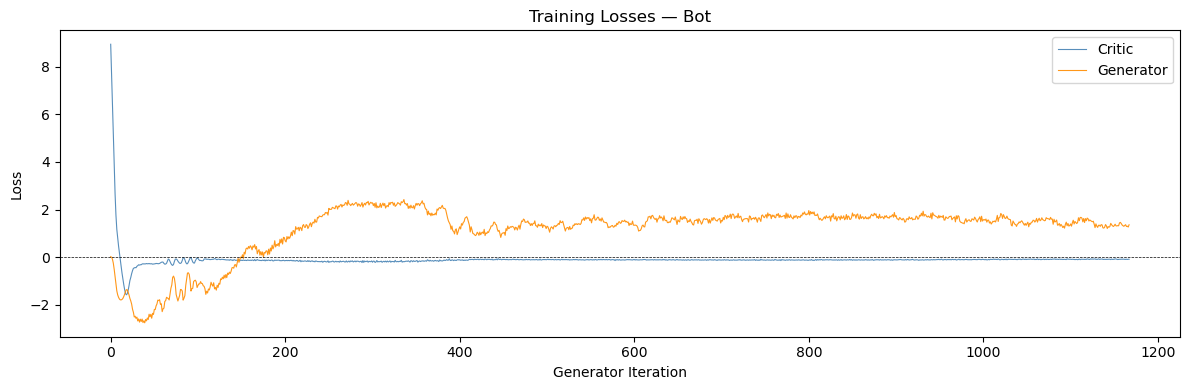

In [ ]:
# save PNG to fidelity dir and display inline
gan.plot_losses(TEST_LABEL, FIDELITY_DIR)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gan.c_losses, label='Critic',    color='steelblue',  linewidth=0.8, alpha=0.9)
ax.plot(gan.g_losses, label='Generator', color='darkorange', linewidth=0.8, alpha=0.9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_title(f'Training Losses — {TEST_LABEL}')
ax.set_xlabel('Generator Iteration')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Fidelity checks of data

Confirm pipeline end to end with debug statements, check correct shape and values, and that inverse-transformed values end up in a plausible range.
Added: large fidelity checks in WGAN-GP implementation:
KS-value: compare real to synthetic data by analysing the max distance between distribution functions. Lower = better. (Statistical)
KDE plots: A smoothed version of distribution (kind of like a histogram), used to visualize the shape of data. (Visual)
Correlation matrix: Pairwise correlation (Pearson), used to check if data preserved feature relationships. (Structural)
TSTR: Train on Synthetic, Test on Real - train a quick model (RandomForest) on the synthetic data and then test the model on real data, to see if the synthetic data can be useful to a model in learning correct classification. (Practical)

KS-value used to be the gatekeeper for whether synthetic data was acceptable or not, but it does poorly on discrete values (a lot of network flow data is discrete) - so TSTR is instead used as the threshold for evaluating fidelity (TSTR > 0.55 to pass)

In [ ]:
import importlib
import wgan_gp
importlib.reload(wgan_gp)
from wgan_gp import evaluate_fidelity

synthetic_scaled = gan.generate(n_synth)

print(f"Generated shape : {synthetic_scaled.shape}")
print(f"Value range     : [{synthetic_scaled.min():.4f}, {synthetic_scaled.max():.4f}]")
print(f"NaN count       : {np.isnan(synthetic_scaled).sum()}")
print(f"Inf count       : {np.isinf(synthetic_scaled).sum()}")

# inverse transform back to original feature scale
synthetic_raw = scaler.inverse_transform(synthetic_scaled).astype(np.float32)
df_synth = pd.DataFrame(synthetic_raw, columns=FEATURE_NAMES)
df_real  = pd.DataFrame(
    scaler.inverse_transform(X_label).astype(np.float32),
    columns=FEATURE_NAMES
)

# reverse the log clipping on Flow Packets/s
df_synth['Flow Packets/s'] = np.expm1(df_synth['Flow Packets/s'])
df_real['Flow Packets/s']  = np.expm1(df_real['Flow Packets/s'])

# cast both to float64 for consistent KS testing
df_real  = df_real.astype(np.float64)
df_synth = df_synth.astype(np.float64)

# build real benign reference for tstr/trts tests
df_real_benign = pd.DataFrame(
    scaler.inverse_transform(X_scaled[y == 'BENIGN']).astype(np.float32),
    columns=FEATURE_NAMES
)
df_real_benign['Flow Packets/s'] = np.expm1(df_real_benign['Flow Packets/s'])
df_real_benign = df_real_benign.astype(np.float64)

# postprocessing: we have to clip the values of synthetic to the real observed bounds (Flow Packets/s blows up for example)
# trim edge-case outliers caused by Tanh boundary
# only affects values outside of real data range
for col in FEATURE_NAMES:
    df_synth[col] = df_synth[col].clip(
        lower=df_real[col].min(),
        upper=df_real[col].max()
    )

# conditional snapping on Init_Win_bytes_backward:
# only applied if real data has a dominant discrete spike (>30% mass on top value)
# generator cannot reproduce point masses so snap to nearest observed top value
real_counts = df_real['Init_Win_bytes_backward'].round(0).value_counts(normalize=True)
top_share   = real_counts.iloc[0]
if top_share > 0.3:
    top_values = real_counts.head(5).index.tolist()
    df_synth['Init_Win_bytes_backward'] = df_synth['Init_Win_bytes_backward'].apply(
        lambda v: min(top_values, key=lambda x: abs(x - v))
    )
    print(f"Init_Win_bytes_backward snapping applied (top value share: {top_share:.2%})")
else:
    print(f"Init_Win_bytes_backward snapping skipped (top value share: {top_share:.2%})")

# fidelity evaluation - TSTR recall is the pass/fail threshold, KS is informational
safe_name = TEST_LABEL.replace(" ", "_").replace("/", "_")
out_path  = os.path.join(SYNTH_DIR, f"{safe_name}_synthetic.csv")

passed, ks_report, tstr_results = evaluate_fidelity(
    X_real         = df_real.values,
    X_synth        = df_synth.values,
    label          = TEST_LABEL,
    feature_names  = FEATURE_NAMES,
    save_dir       = FIDELITY_DIR,
    df_real_benign = df_real_benign,
)

df_synth["Label"] = TEST_LABEL
if passed:
    df_synth.to_csv(out_path, index=False)
    print(f"Passed — {n_synth} rows saved to {out_path}")
else:
    warn_path = out_path.replace(".csv", "_REVIEW.csv")
    df_synth.to_csv(warn_path, index=False)
    print(f"Failed — saved for review to {warn_path}")

Generated shape : (9740, 15)
Value range     : [-1.0000, 1.0000]
NaN count       : 0
Inf count       : 0
Init_Win_bytes_backward snapping applied (top value share: 34.96%)
X_real  dtype: float64  range: [-0.000, 9554872.000]
X_synth dtype: float64 range: [-0.000, 9554682.000]
X_real  sample (first row): [9.00000000e+00 3.21999908e+02 3.22000031e+02 3.57777710e+01
 2.56000153e+02 2.98990339e-01 5.26849000e+06 2.33528015e+02
 2.96000000e+02 2.96000000e+02 3.22000031e+02 3.04210434e+01
 8.42426172e+03 2.92000000e+04 1.10000580e+02]
X_synth sample (first row): [1.05904579e+00 5.13294458e-01 1.18848066e+01 1.27478151e+01
 1.23150415e+01 2.96069824e+04 1.45741797e+05 1.13674824e+04
 2.14827518e+01 2.12420101e+01 4.12927818e+00 5.25640440e+00
 4.27136078e+02 2.37000000e+02 1.25500000e+03]
KS running on 1948 samples (real: 1948, synth: 9740)
Mean KS: 0.4859
KS report saved to outputs/synthetic/fidelity\Bot_ks_report.csv
  KDE plot  : outputs/synthetic/fidelity\Bot_kde.png
  Correlation plot  :

In [ ]:
# portscan debug
# investigate portscan values to see what went wrong
mask_ps = (y == 'PortScan').values
df_portscan = pd.DataFrame(
    scaler.inverse_transform(X_scaled[mask_ps]).astype(np.float32),
    columns=FEATURE_NAMES
)
print(df_portscan.describe())
print("\nNear-zero variance features:")
print((df_portscan.std() < 1.0).sum(), "features with std < 1.0")
print(df_portscan.std().sort_values())

       Total Fwd Packets  Total Length of Fwd Packets  Fwd Packet Length Max  \
count       90694.000000                 90694.000000           90694.000000   
mean            1.029682                     1.170641               1.136744   
std             0.315928                     7.443117               4.581302   
min             1.000000                     0.000000               0.000000   
25%             1.000000                     0.000000               0.000000   
50%             1.000000                     0.000000               0.000000   
75%             1.000000                     1.999911               2.000019   
max            51.000000                  1473.000122             397.000061   

       Fwd Packet Length Mean  Bwd Packet Length Max  Flow Packets/s  \
count            90694.000000           90694.000000    90694.000000   
mean                 1.031099              10.888899       10.689250   
std                  1.502299             159.500595        0.9